# Notebook: Predicción de pTM e ipTM desde embeddings

## Instalación

In [1]:
!pip install numpy pandas scikit-learn xgboost matplotlib seaborn torch

Defaulting to user installation because normal site-packages is not writeable


## Imports

In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim

## Cargar dataset

In [13]:
df = pd.read_csv("dataset.csv")

print(df.shape)

df.head()

(28800, 8)


,mpnn,plddt,ptm,i_ptm,pae,i_pae,rmsd,seq
0,1.610,0.759,0.716,0.687,6.965,7.368,5.898,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...
1,1.593,0.589,0.664,0.493,10.559,11.163,1.549,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...
2,1.599,0.787,0.728,0.721,6.648,7.012,5.711,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...
3,1.578,0.759,0.716,0.687,6.965,7.368,5.898,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...
4,1.656,0.762,0.706,0.696,7.129,7.536,4.984,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...


## Cargar embeddings

In [14]:
embeddings = np.load("protein_embeddings.npy")

print("Embedding shape:", embeddings.shape)

Embedding shape: (28800, 2560)


## Cargar embedding de PDL1

In [15]:
pdl1_embedding = np.load("pdl1_embedding.npy")

print(pdl1_embedding.shape)

(1280,)


## Targets

In [16]:
y = df[["ptm", "i_ptm"]].values

print(y.shape)

(28800, 2)


## Exploración del dataset

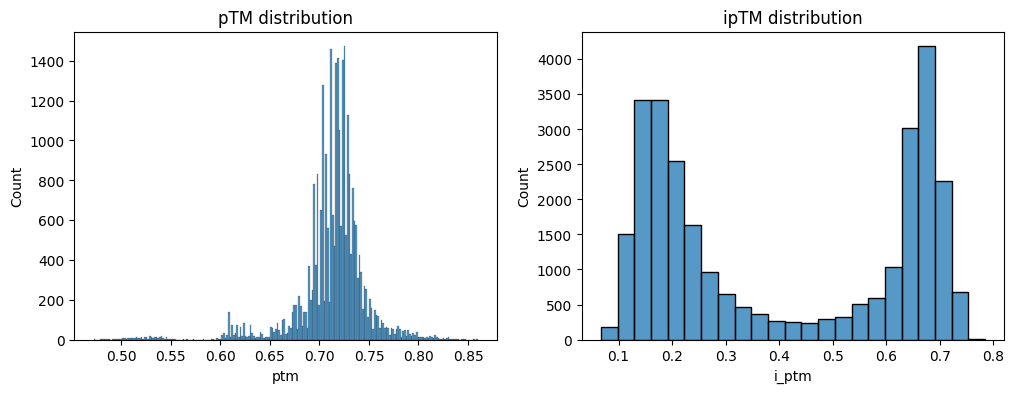

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df["ptm"], ax=axes[0])
axes[0].set_title("pTM distribution")

sns.histplot(df["i_ptm"], ax=axes[1])
axes[1].set_title("ipTM distribution")

plt.show()

## Correlaciones

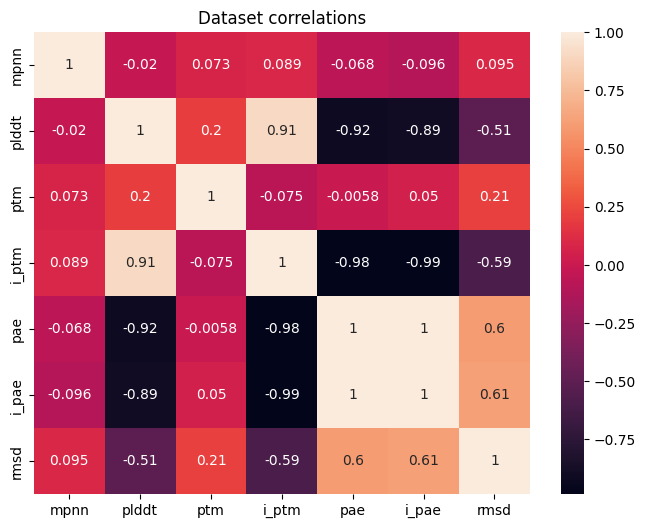

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Dataset correlations")

plt.show()

## Preparar features

In [19]:
X = embeddings

print(X.shape)

(28800, 2560)


## Train/Test split

In [20]:
print("Dataset shape:", df.shape)

print("Embeddings shape:", embeddings.shape)

print("Targets shape:", y.shape)

Dataset shape: (28800, 8)
Embeddings shape: (28800, 2560)
Targets shape: (28800, 2)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Escalado

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA

In [23]:
pca = PCA(n_components=256)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)

(23040, 256)


## Varianza explicada

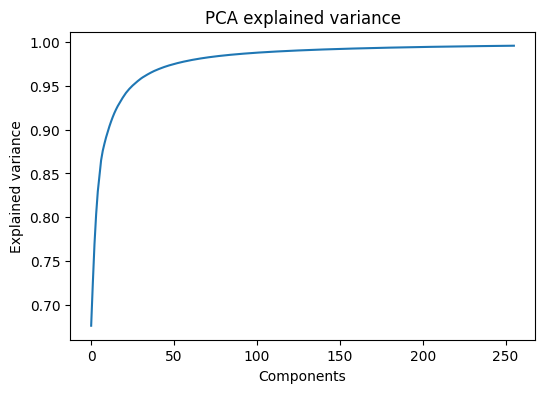

In [24]:
plt.figure(figsize=(6,4))

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel("Components")
plt.ylabel("Explained variance")

plt.title("PCA explained variance")

plt.show()

## Función de evaluación

In [25]:
def evaluate_model(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)

    return mse, mae, r2

## Decision Tree

In [26]:
dt = DecisionTreeRegressor(max_depth=10)

dt.fit(X_train_pca, y_train)

pred_dt = dt.predict(X_test_pca)

evaluate_model("Decision Tree", y_test, pred_dt)

Decision Tree
MSE: 0.00356334842242619
MAE: 0.029442563824474695
R2: 0.7974597139236483


(0.00356334842242619, 0.029442563824474695, 0.7974597139236483)

## Random Forest

In [27]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

pred_rf = rf.predict(X_test_pca)

evaluate_model("Random Forest", y_test, pred_rf)

Random Forest
MSE: 0.0016799963456281782
MAE: 0.017455944933863692
R2: 0.903998061335131


(0.0016799963456281782, 0.017455944933863692, 0.903998061335131)

## XGBoost

In [28]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_pca, y_train)

pred_xgb = xgb_model.predict(X_test_pca)

evaluate_model("XGBoost", y_test, pred_xgb)

XGBoost
MSE: 0.0014876160489143834
MAE: 0.014707208670282461
R2: 0.9266074740846175


(0.0014876160489143834, 0.014707208670282461, 0.9266074740846175)

## Red neuronal profunda

In [29]:
class Net(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,64),
            nn.ReLU(),

            nn.Linear(64,2)
        )

    def forward(self,x):

        return self.model(x)

## Preparar tensores

In [30]:
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)

## Entrenamiento

In [31]:
model = Net()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50

losses = []

for epoch in range(epochs):

    pred = model(X_train_t)

    loss = criterion(pred, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:

        print("epoch",epoch,"loss",loss.item())

epoch 0 loss 0.4513741731643677
epoch 10 loss 0.020000088959932327
epoch 20 loss 0.004399189725518227
epoch 30 loss 0.005330418702214956
epoch 40 loss 0.003518439596518874


## Curva de entrenamiento

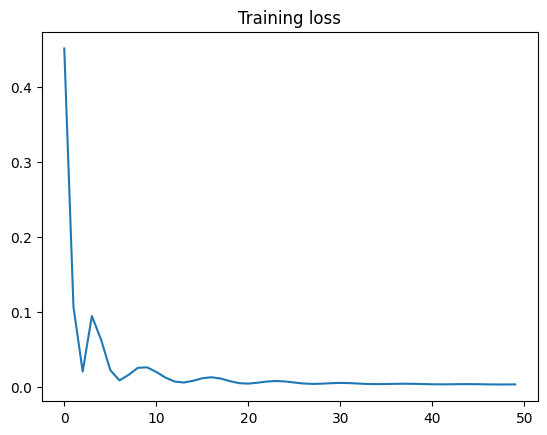

In [32]:
plt.plot(losses)

plt.title("Training loss")

plt.show()

## Predicciones NN

In [33]:
model.eval()

with torch.no_grad():

    pred_nn = model(X_test_t).numpy()

evaluate_model("Neural Network", y_test, pred_nn)

Neural Network
MSE: 0.003635878495882138
MAE: 0.038380267458253924
R2: 0.6731777335724851


(0.003635878495882138, 0.038380267458253924, 0.6731777335724851)

## Comparación de modelos

In [34]:
models = {

"DecisionTree":pred_dt,
"RandomForest":pred_rf,
"XGBoost":pred_xgb,
"NeuralNet":pred_nn
}

for name,pred in models.items():

    r2 = r2_score(y_test,pred)

    print(name,r2)

DecisionTree 0.7974597139236483
RandomForest 0.903998061335131
XGBoost 0.9266074740846175
NeuralNet 0.6731777335724851


## Scatter plots (real vs predicho)

In [35]:
def plot_predictions(true, pred, title):

    plt.figure(figsize=(5,5))

    plt.scatter(true, pred, alpha=0.4)

    plt.xlabel("True")
    plt.ylabel("Predicted")

    plt.title(title)

    plt.plot([0,1],[0,1])

    plt.show()

## pTM

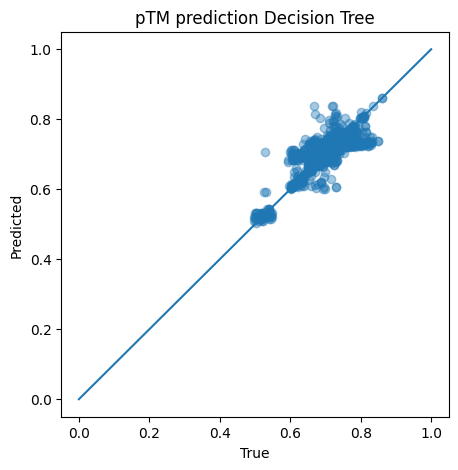

In [39]:
plot_predictions(y_test[:,0], pred_dt[:,0], "pTM prediction Decision Tree")

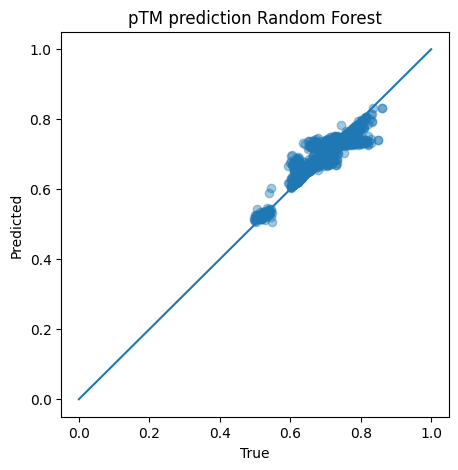

In [40]:
plot_predictions(y_test[:,0], pred_rf[:,0], "pTM prediction Random Forest")

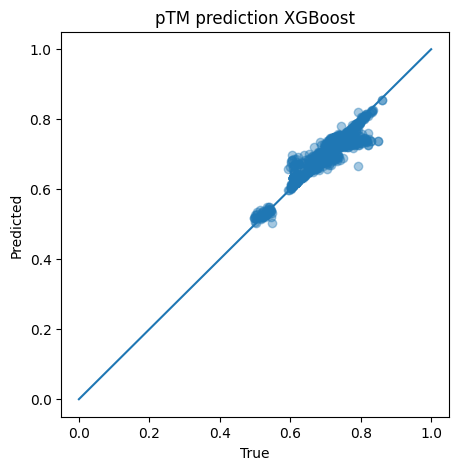

In [41]:
plot_predictions(y_test[:,0], pred_xgb[:,0], "pTM prediction XGBoost")

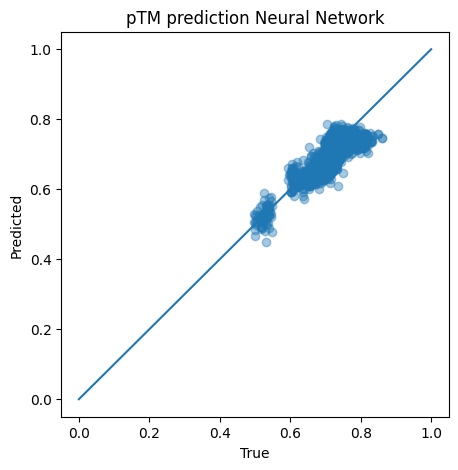

In [42]:
plot_predictions(y_test[:,0], pred_nn[:,0], "pTM prediction Neural Network")

## ipTM

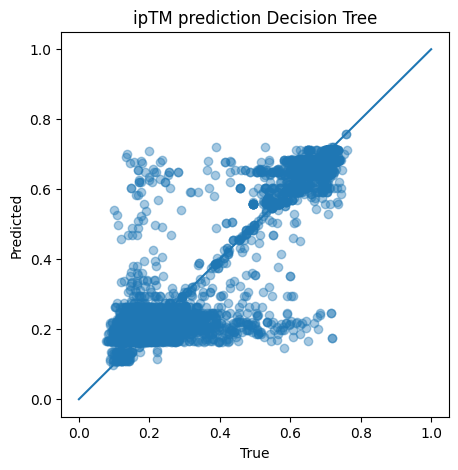

In [43]:
plot_predictions(y_test[:,1], pred_dt[:,1], "ipTM prediction Decision Tree")

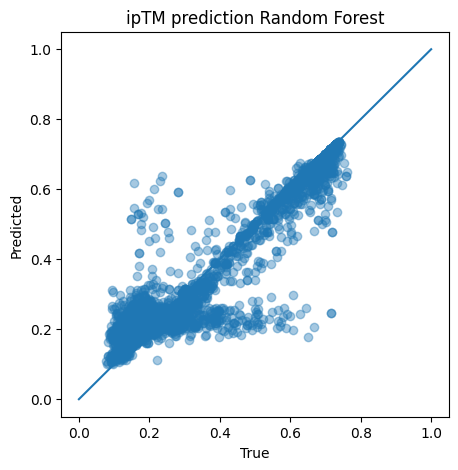

In [44]:
plot_predictions(y_test[:,1], pred_rf[:,1], "ipTM prediction Random Forest")

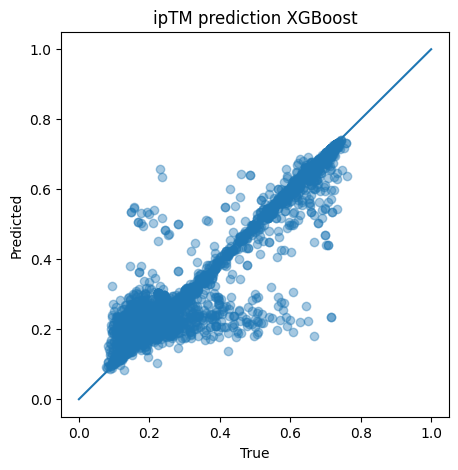

In [45]:
plot_predictions(y_test[:,1], pred_xgb[:,1], "ipTM prediction XGBoost")

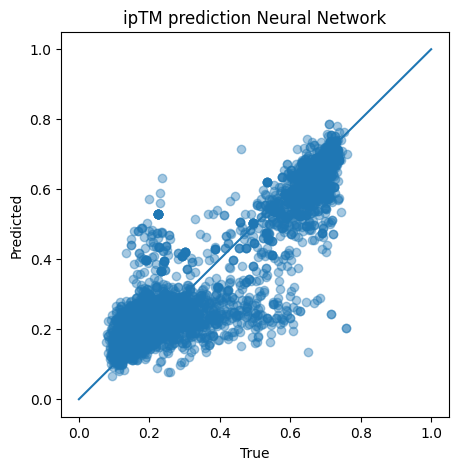

In [46]:
plot_predictions(y_test[:,1], pred_nn[:,1], "ipTM prediction Neural Network")

## Guardar modelos

In [38]:
import joblib

joblib.dump(pca,"pca.pkl")
joblib.dump(xgb_model,"xgb_model.pkl")
joblib.dump(rf,"rf_model.pkl")
joblib.dump(dt,"dt_model.pkl")

torch.save(model.state_dict(),"nn_model.pt")